Removed no burn in


(704000, 2) (256, 256)


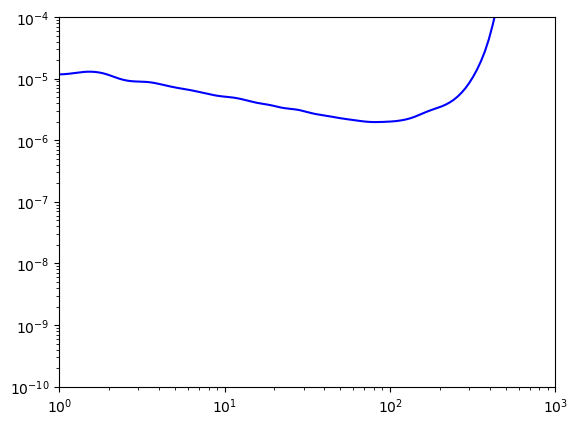

In [1]:
import corner
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from getdist import MCSamples, plots
from scipy.ndimage import gaussian_filter1d

effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]


threshold = chi2.ppf(0.95, df=2) # 95% confidence level for 2 parameters

fig, ax = plt.subplots()

stacked_list_2d = []

for file_id in effective_data_file:
    path_2d = f'./Bin/smellycat260610/data/2d_m{file_id}_5e5_p32_log.npy'
    arr_2d = np.load(path_2d)
    stacked_list_2d.append(arr_2d)

stacked_arr_2d = np.concatenate(stacked_list_2d, axis=0)    # 2D
stacked_sample_2d = MCSamples(samples=stacked_arr_2d, names=['logm', 'loglam'], labels=['log(m)', 'log(λ)'], settings={'smooth_scale_2D': -1})

density_2d = stacked_sample_2d.get2DDensity('logm', 'loglam')
print(stacked_arr_2d.shape, density_2d.P.shape)

level_95 = density_2d.getContourLevels([0.95])[0]

# Initialize arrays for our clean line
x_upper_2d = density_2d.x
y_upper_2d = np.full_like(x_upper_2d, np.nan) 

# Ensure grid is sliced correctly (usually shape is (ny, nx))
P_grid_2d = density_2d.P if density_2d.P.shape == (len(density_2d.y), len(density_2d.x)) else density_2d.P.T

# Scan vertically through every single x-column
for ix in range(len(x_upper_2d)):
    y_profile = P_grid_2d[:, ix]
    
    # Find all y-indices in this column that are inside the 95% contour
    inside_indices = np.where(y_profile >= level_95)[0]
    
    if len(inside_indices) > 0:
        # The highest y-value index is the last one (since density.y is sorted ascending)
        max_y_idx = inside_indices[-1]
        y_upper_2d[ix] = density_2d.y[max_y_idx]

valid = ~np.isnan(y_upper_2d)
y_upper_2d[valid] = gaussian_filter1d(y_upper_2d[valid], sigma=2)   # smooth

# plot in the first subplot and leave the rest blank
ax.plot(10**x_upper_2d, 10**y_upper_2d, color='blue', label='95% Contour')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-10, 1e-4)
fig


Removed no burn in
(32000, 2) (256, 256)


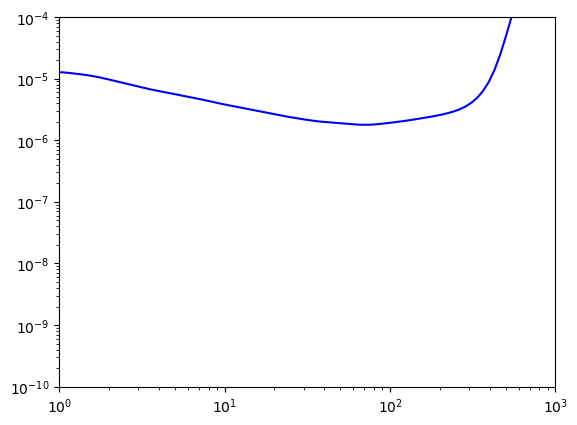

In [3]:
fig, ax = plt.subplots()

arr_1d = np.load(r'F:/Neutrino_SI/Bin/smellycat260610/data/1d_8p_1e6_p32_log.npy')[:, -2:]  # 1D
sample_1d = MCSamples(samples=arr_1d, names=['logm', 'loglam'])

density_1d = sample_1d.get2DDensity('logm', 'loglam')

level_95 = density_1d.getContourLevels([0.95])[0]

x_upper_1d = density_1d.x
y_upper_1d = np.full_like(x_upper_1d, np.nan)

print(arr_1d.shape, density_1d.P.shape)

P_grid_1d = density_1d.P if density_1d.P.shape == (len(density_1d.y), len(density_1d.x)) else density_1d.P.T

for ix in range(len(x_upper_1d)):
    y_profile = P_grid_1d[:, ix]
    
    inside_indices = np.where(y_profile >= level_95)[0]
    
    if len(inside_indices) > 0:
        max_y_idx = inside_indices[-1]
        y_upper_1d[ix] = density_1d.y[max_y_idx]

valid = ~np.isnan(y_upper_1d)
y_upper_1d[valid] = gaussian_filter1d(y_upper_1d[valid], sigma=2)   # smooth

ax.plot(10**x_upper_1d, 10**y_upper_1d, color='blue', label='95% Contour')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-10, 1e-4)
fig
